# Notebook 04 — Naive Bayes · KNN · Logistic Regression (Cài đặt từ đầu)

Tất cả các model được cài đặt thủ công hoàn toàn bằng NumPy — **không sử dụng bất kỳ lớp model nào từ thư viện** (sklearn, etc.).

| Model | Ý tưởng |
|---|---|
| Gaussian Naive Bayes | Định lý Bayes + phân phối Gaussian cho mỗi đặc trưng |
| K-Nearest Neighbors | Khoảng cách Euclidean + bình chọn k láng giềng gần nhất |
| Logistic Regression | Gradient Descent trên BCE Loss (One-vs-Rest) |

## 1. Cài đặt môi trường

In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

SEED = 42
TARGET = "label"
np.random.seed(SEED)

PROCESSED_DIR = "../data/processed"
RAW_PATH  = "../data/raw/Crop_recommendation.csv"
MODELS_DIR = "../saved_models"

print("Setup hoàn tất.")

Setup hoàn tất.


## 2. Nạp dữ liệu từ `data/processed`

- **Nếu** thư mục `data/processed` đã có file CSV (từ notebook 02) → nạp trực tiếp.
- **Ngược lại** → nạp raw data, thực hiện feature engineering, chuẩn hóa, label encoding, rồi chia 3 tập và lưu vào `data/processed`.

Tỉ lệ chia: **70% train · 10% validation · 20% test** (stratified theo lớp).

In [2]:
def _feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["total_npk"] = df["N"] + df["P"] + df["K"]
    df["ratio_n_p"] = df["N"] / (df["P"] + 1e-9)
    df["ratio_n_k"] = df["N"] / (df["K"] + 1e-9)
    df["ratio_p_k"] = df["P"] / (df["K"] + 1e-9)
    df["temp_humidity"] = df["temperature"] * df["humidity"]
    df["log_rainfall"]  = np.log(df["rainfall"] + 1.0)
    return df


def _stratified_split(X: np.ndarray, y: np.ndarray,
                       train_ratio=0.70, val_ratio=0.10,
                       seed=SEED):
# Chia tập dữ liệu
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []

    for c in np.unique(y):
        idx = rng.permutation(np.where(y == c)[0])
        n = len(idx)
        n_train = int(train_ratio * n)
        n_val   = int(val_ratio   * n)
        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train : n_train + n_val])
        test_idx.extend(idx[n_train + n_val :])

    return (X[train_idx], y[train_idx],
            X[val_idx],   y[val_idx],
            X[test_idx],  y[test_idx])


def _preprocess_raw() -> tuple:
    print("  → Nạp raw data:", RAW_PATH)
    df = pd.read_csv(RAW_PATH)

    # Feature engineering
    df = _feature_engineering(df)

    # Encoding string -> int
    le = LabelEncoder()
    df[TARGET] = le.fit_transform(df[TARGET])

    feature_cols = [c for c in df.columns if c != TARGET]
    X = df[feature_cols].values.astype(float)
    y = df[TARGET].values.astype(int)

    # Chuẩn hóa Z-score
    mu = X.mean(axis=0)
    sig = X.std(axis=0) + 1e-9
    X = (X - mu) / sig

    # Chia tập
    X_tr, y_tr, X_v, y_v, X_te, y_te = _stratified_split(X, y)

    # Lưu vào data/processed
    os.makedirs(PROCESSED_DIR, exist_ok=True)
    for subset, Xs, ys, name in [
        ("train", X_tr, y_tr, "train_preprocessed.csv"),
        ("val", X_v,  y_v, "val_preprocessed.csv"),
        ("test", X_te, y_te, "test_preprocessed.csv"),
    ]:
        out = pd.DataFrame(Xs, columns=feature_cols)
        out[TARGET] = ys
        out.to_csv(os.path.join(PROCESSED_DIR, name), index=False)
        print(f"  → Đã lưu {name}  ({Xs.shape})")

    return X_tr, y_tr, X_v, y_v, X_te, y_te


def load_data() -> tuple:
    """Nạp 3 tập dữ liệu từ data/processed (hoặc tự tạo nếu chưa có)."""
    tr = os.path.join(PROCESSED_DIR, "train_preprocessed.csv")
    vl = os.path.join(PROCESSED_DIR, "val_preprocessed.csv")
    te = os.path.join(PROCESSED_DIR, "test_preprocessed.csv")

    if all(os.path.exists(p) for p in [tr, vl, te]):
        print("Nạp dữ liệu từ data/processed (đã tồn tại)…")
        train_df = pd.read_csv(tr)
        val_df = pd.read_csv(vl)
        test_df  = pd.read_csv(te)

        X_tr = train_df.drop(columns=[TARGET]).values
        y_tr = train_df[TARGET].values
        X_v = val_df.drop(columns=[TARGET]).values
        y_v = val_df[TARGET].values
        X_te = test_df.drop(columns=[TARGET]).values
        y_te = test_df[TARGET].values
    else:
        print("Chưa có data/processed → tự preprocess từ raw data…")
        X_tr, y_tr, X_v, y_v, X_te, y_te = _preprocess_raw()

    print(f"\nTrain : {X_tr.shape}  |  Val : {X_v.shape}  |  Test : {X_te.shape}")
    print(f"Số lớp: {len(np.unique(y_tr))}")
    return X_tr, y_tr, X_v, y_v, X_te, y_te


X_train, y_train, X_val, y_val, X_test, y_test = load_data()

Nạp dữ liệu từ data/processed (đã tồn tại)…

Train : (1540, 13)  |  Val : (220, 13)  |  Test : (440, 13)
Số lớp: 22


---
## 3. Gaussian Naive Bayes (Cài đặt từ đầu)

### Lý thuyết

**Định lý Bayes:**
$$P(Y{=}c \mid \mathbf{x}) \propto P(Y{=}c) \cdot \prod_{j=1}^{d} P(x_j \mid Y{=}c)$$

**Giả thiết "Naive":** Các đặc trưng độc lập có điều kiện với nhau.

**Mô hình Gaussian:** Mỗi đặc trưng $x_j$ conditioned on class $c$ tuân theo phân phối chuẩn:
$$P(x_j \mid Y{=}c) = \frac{1}{\sqrt{2\pi\,\sigma_{cj}^2}} \exp\!\left(-\frac{(x_j - \mu_{cj})^2}{2\sigma_{cj}^2}\right)$$

**Huấn luyện:** Ước lượng MLE cho từng lớp $c$ và đặc trưng $j$:
- Prior: $\pi_c = N_c / N$
- Mean: $\mu_{cj} = \frac{1}{N_c}\sum_{i:y_i=c} x_{ij}$
- Variance: $\sigma_{cj}^2 = \frac{1}{N_c}\sum_{i:y_i=c}(x_{ij} - \mu_{cj})^2$

**Dự đoán (log-space để tránh underflow):**
$$\hat{y} = \arg\max_c\left[\ln\pi_c + \sum_{j=1}^{d}\ln P(x_j \mid \mu_{cj},\sigma_{cj}^2)\right]$$

In [3]:
class GaussianNaiveBayes:

    def __init__(self, var_smoothing: float = 1e-9):
        self.var_smoothing = var_smoothing
        self.classes_ = None   
        self.log_priors_  = None   
        self.means_= None   
        self.vars_ = None  


    def fit(self, X: np.ndarray, y: np.ndarray) -> "GaussianNaiveBayes":
        self.classes_ = np.unique(y)
        K, d = len(self.classes_), X.shape[1]

        self.log_priors_ = np.empty(K)
        self.means_ = np.empty((K, d))
        self.vars_ = np.empty((K, d))

        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]                
            Nc = X_c.shape[0]

            self.log_priors_[idx] = np.log(Nc / X.shape[0])

            self.means_[idx] = X_c.mean(axis=0)
            self.vars_[idx] = X_c.var(axis=0) + self.var_smoothing

        return self



    def _log_likelihood(self, X: np.ndarray) -> np.ndarray:
        n = X.shape[0]
        log_post = np.empty((n, len(self.classes_)))

        for idx in range(len(self.classes_)):
            mu = self.means_[idx]   
            var = self.vars_[idx] 
            log_pdf = -0.5 * np.sum(
                np.log(2.0 * np.pi * var) + ((X - mu) ** 2) / var,
                axis=1
            ) 

            log_post[:, idx] = self.log_priors_[idx] + log_pdf

        return log_post  
    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.classes_[np.argmax(self._log_likelihood(X), axis=1)]


def train_naive_bayes(
    X_train: np.ndarray,
    y_train: np.ndarray,
    var_smoothing: float = 1e-9,
) -> GaussianNaiveBayes:

    model = GaussianNaiveBayes(var_smoothing=var_smoothing)
    model.fit(X_train, y_train)
    return model


---
## 4. K-Nearest Neighbors

### Lý thuyết

KNN là thuật toán **instance-based learning** (lazy learning) — không xây dựng mô hình rõ ràng, chỉ ghi nhớ toàn bộ tập train.

**Khoảng cách Euclidean (L₂):**
$$d(\mathbf{x}, \mathbf{x}') = \sqrt{\sum_{j=1}^{d}(x_j - x'_j)^2}$$

**Dự đoán:** Với mỗi điểm test $\mathbf{x}$:
1. Tìm $k$ điểm train gần nhất: $\mathcal{N}_k(\mathbf{x}) = \{\mathbf{x}^{(1)},\ldots,\mathbf{x}^{(k)}\}$
2. Bình chọn đa số (majority vote):
$$\hat{y} = \arg\max_c \sum_{i \in \mathcal{N}_k(\mathbf{x})} \mathbf{1}[y^{(i)} = c]$$

**Độ phức tạp dự đoán:** $O(n_{train} \cdot d)$ cho mỗi điểm test.

In [4]:
class KNearestNeighbors:
    def __init__(self, k: int = 5):
        self.k = k
        self.X_train_ = None
        self.y_train_ = None
        self.classes_ = None
    def fit(self, X: np.ndarray, y: np.ndarray) -> "KNearestNeighbors":
        self.X_train_ = X.copy()
        self.y_train_ = y.copy()
        self.classes_ = np.unique(y)
        return self

    def _euclidean_distances(self, X: np.ndarray) -> np.ndarray:

        sq_test  = np.sum(X ** 2, axis=1, keepdims=True)

        sq_train = np.sum(self.X_train_ ** 2, axis=1)

        dot = X @ self.X_train_.T

        sq_dist = sq_test + sq_train - 2.0 * dot
        sq_dist = np.clip(sq_dist, 0.0, None) 
        return np.sqrt(sq_dist)

    # ------------------------------------------------------------------
    def predict(self, X: np.ndarray) -> np.ndarray:
        dists = self._euclidean_distances(X)   
        k_idx = np.argsort(dists, axis=1)[:, : self.k]   
        k_labels = self.y_train_[k_idx]         

        
        preds = np.array([
            Counter(row.tolist()).most_common(1)[0][0]
            for row in k_labels
        ])
        return preds


def train_knn(
    X_train: np.ndarray,
    y_train: np.ndarray,
    k: int = 5,
) -> KNearestNeighbors:

    model = KNearestNeighbors(k=k)
    model.fit(X_train, y_train)
    return model


---
## 5. Logistic Regression 

### Lý thuyết

**Chiến lược One-vs-Rest (OvR):** Với bài toán $K$ lớp, huấn luyện $K$ bộ phân loại nhị phân độc lập.

**Hàm Sigmoid:**
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Mô hình xác suất (bộ phân loại thứ $k$):**
$$\hat{p}_k = \sigma(\mathbf{w}_k^\top \tilde{\mathbf{x}})$$
trong đó $\tilde{\mathbf{x}} = [1,\, \mathbf{x}^\top]^\top$ (thêm bias vào vector đặc trưng).

**Hàm mất mát (Binary Cross-Entropy):**
$$\mathcal{L}(\mathbf{w}_k) = -\frac{1}{N}\sum_{i=1}^{N}\Big[y_{ik}\ln\hat{p}_{ik} + (1{-}y_{ik})\ln(1{-}\hat{p}_{ik})\Big]$$

**Gradient:**
$$\nabla_{\mathbf{w}_k}\mathcal{L} = \frac{1}{N}\,\tilde{X}^\top(\hat{\mathbf{p}}_k - \mathbf{y}_k)$$

**Cập nhật trọng số (Gradient Descent):**
$$\mathbf{w}_k \leftarrow \mathbf{w}_k - \eta \cdot \nabla_{\mathbf{w}_k}\mathcal{L}$$

**Dự đoán:**
$$\hat{y} = \arg\max_k\, \sigma(\mathbf{w}_k^\top \tilde{\mathbf{x}})$$

In [5]:
class LogisticRegressionOvR:
    def __init__(self, lr: float = 0.1, n_iters: int = 500):
        self.lr = lr
        self.n_iters = n_iters
        self.W= None  
        self.classes_ = None

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500.0, 500.0)))

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LogisticRegressionOvR":
 
        X_b = np.c_[np.ones(X.shape[0]), X]  
        m, d1 = X_b.shape

        self.classes_ = np.unique(y)
        K = len(self.classes_)
        self.W = np.zeros((K, d1))

        for idx, c in enumerate(self.classes_):
    
            y_bin = (y == c).astype(float)  
            w_k = np.zeros(d1)

            for _ in range(self.n_iters):
                p_hat = self._sigmoid(X_b @ w_k) 

                grad = (X_b.T @ (p_hat - y_bin)) / m

                w_k -= self.lr * grad

            self.W[idx] = w_k

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X_b  = np.c_[np.ones(X.shape[0]), X] 
        scores = X_b @ self.W.T                 
        return self.classes_[np.argmax(scores, axis=1)]


def train_logistic_regression(
    X_train: np.ndarray,
    y_train: np.ndarray,
    lr: float = 0.1,
    n_iters: int = 500,
) -> LogisticRegressionOvR:
    model = LogisticRegressionOvR(lr=lr, n_iters=n_iters)
    model.fit(X_train, y_train)
    return model


---
## 6. Huấn luyện các mô hình

In [6]:
import time

# Naive Bayes
print("Đang huấn luyện Gaussian Naive Bayes…")
t0  = time.time()
nb  = train_naive_bayes(X_train, y_train, var_smoothing=1e-9)
print(f"  Xong — {time.time()-t0:.2f}s")

# KNN
print("\nĐang huấn luyện KNN (k=7)…")
t0  = time.time()
knn = train_knn(X_train, y_train, k=7)
print(f"  Xong — {time.time()-t0:.2f}s")

# Logistic Regression
print("\nĐang huấn luyện Logistic Regression (lr=0.1, n_iters=500)…")
t0  = time.time()
lr_model = train_logistic_regression(X_train, y_train, lr=0.1, n_iters=500)
print(f"  Xong — {time.time()-t0:.2f}s")

print("\nHuấn luyện hoàn tất!")

Đang huấn luyện Gaussian Naive Bayes…
  Xong — 0.00s

Đang huấn luyện KNN (k=7)…
  Xong — 0.00s

Đang huấn luyện Logistic Regression (lr=0.1, n_iters=500)…


  Xong — 0.21s

Huấn luyện hoàn tất!


---
## 7. Đánh giá và so sánh kết quả

In [7]:
def evaluate(name: str, model, X_v, y_v, X_te, y_te) -> dict:
    pred_v  = model.predict(X_v)
    pred_te = model.predict(X_te)

    return {
        "Model" : name,
        "Val Accuracy" : round(accuracy_score(y_v, pred_v), 4),
        "Test Accuracy": round(accuracy_score(y_te, pred_te), 4),
        "Val F1 (w)" : round(f1_score(y_v, pred_v, average="weighted"), 4),
        "Test F1 (w)" : round(f1_score(y_te, pred_te, average="weighted"), 4),
        "Val Precision" : round(precision_score(y_v, pred_v, average="weighted"), 4),
        "Test Precision" : round(precision_score(y_te, pred_te, average="weighted"), 4),
        "Val Recall" : round(recall_score(y_v, pred_v, average="weighted"), 4),
        "Test Recall" : round(recall_score(y_te,pred_te, average="weighted"), 4),
    }


results = [
    evaluate("Naive Bayes (Manual)", nb, X_val, y_val, X_test, y_test),
    evaluate("KNN k=7 (Manual)", knn, X_val, y_val, X_test, y_test),
    evaluate("Logistic Regression (Manual)", lr_model, X_val, y_val, X_test, y_test),
]

df_results = pd.DataFrame(results)

metric_cols = [
    "Val Accuracy", "Test Accuracy",
    "Val F1 (w)", "Test F1 (w)",
    "Val Precision","Test Precision",
    "Val Recall", "Test Recall",
]

styled = (
    df_results.style
    .set_caption("Kết quả — Naive Bayes · KNN · Logistic Regression (cài đặt thủ công)")
    .set_properties(**{"text-align": "center"})
    .format({col: "{:.4f}" for col in metric_cols})
    .highlight_max(subset=metric_cols, color="#c6efce")
)
display(styled)

best_idx = df_results["Test Accuracy"].idxmax()
best_model = df_results.loc[best_idx, "Model"]
best_acc = df_results.loc[best_idx, "Test Accuracy"]
print(f"\nMô hình tốt nhất (Test Accuracy): {best_model}  →  {best_acc:.4f}")

,Model,Val Accuracy,Test Accuracy,Val F1 (w),Test F1 (w),Val Precision,Test Precision,Val Recall,Test Recall
0,Naive Bayes (Manual),1.0000,0.9909,1.0000,0.9909,1.0000,0.9913,1.0000,0.9909
1,KNN k=7 (Manual),0.9773,0.9727,0.9769,0.9723,0.9812,0.9747,0.9773,0.9727
2,Logistic Regression (Manual),0.8864,0.8636,0.8733,0.8498,0.9219,0.8972,0.8864,0.8636



Mô hình tốt nhất (Test Accuracy): Naive Bayes (Manual)  →  0.9909


### Biểu đồ so sánh Accuracy

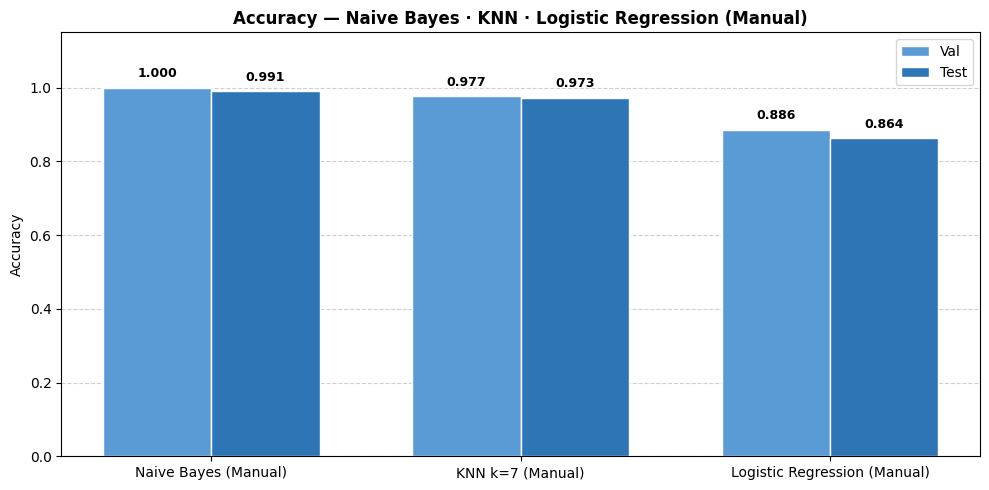

In [8]:
model_names = df_results["Model"].tolist()
val_accs = df_results["Val Accuracy"].tolist()
test_accs = df_results["Test Accuracy"].tolist()

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, val_accs,  width, label="Val",  color="#5B9BD5", edgecolor="white")
bars2 = ax.bar(x + width/2, test_accs, width, label="Test", color="#2E75B6", edgecolor="white")

ax.set_title("Accuracy — Naive Bayes · KNN · Logistic Regression (Manual)",
             fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.15)
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=10)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


--- Classification Report: Naive Bayes ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       0.91      1.00      0.95        20
           7       1.00      1.00      1.00        20
           8       0.95      0.95      0.95        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       1.00      0.90      0.95        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00    

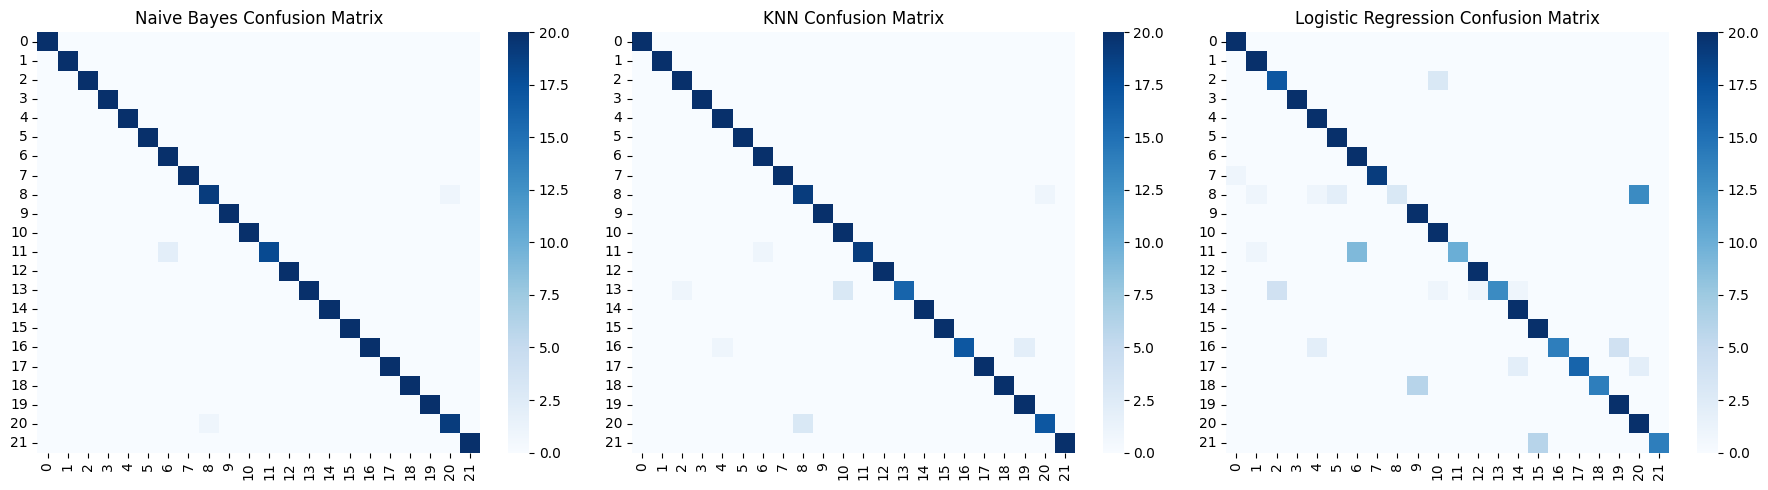

In [9]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

for model_name, model in zip(["Naive Bayes", "KNN", "Logistic Regression"], [nb, knn, lr_model]):
    print(f"\n--- Classification Report: {model_name} ---")
    print(classification_report(y_test, model.predict(X_test)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, model_name, model in zip(axes, ["Naive Bayes", "KNN", "Logistic Regression"], [nb, knn, lr_model]):
    sns.heatmap(confusion_matrix(y_test, model.predict(X_test)), annot=False, cmap='Blues', ax=ax)
    ax.set_title(f'{model_name} Confusion Matrix')
plt.tight_layout()
plt.show()


In [10]:
try:
    print("\n--- So sánh với Baseline (thư viện) ---")
    baseline_df = pd.read_csv('../data/processed/baseline_results.csv')
    # Combine with current results
    combined_df = pd.concat([baseline_df, df_results], ignore_index=True)
    # Display the sorted dataframe by Test Accuracy
    combined_sorted = combined_df.sort_values(by="Test Accuracy", ascending=False)
    display(combined_sorted)
except Exception as e:
    print("Không tìm thấy baseline_results.csv hoặc có lỗi:", e)



--- So sánh với Baseline (thư viện) ---


,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s),Val Accuracy,Test Accuracy,Val F1 (w),Test F1 (w),Val Precision,Test Precision,Val Recall,Test Recall
5,Naive Bayes (Manual),NaN,NaN,NaN,NaN,NaN,1.0000,0.9909,1.0000,0.9909,1.0000,0.9913,1.0000,0.9909
6,KNN k=7 (Manual),NaN,NaN,NaN,NaN,NaN,0.9773,0.9727,0.9769,0.9723,0.9812,0.9747,0.9773,0.9727
7,Logistic Regression (Manual),NaN,NaN,NaN,NaN,NaN,0.8864,0.8636,0.8733,0.8498,0.9219,0.8972,0.8864,0.8636
0,Naive Bayes,0.995455,0.995868,0.995455,0.995443,0.005312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Random Forest,0.995455,0.995868,0.995455,0.995443,0.274397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KNN,0.986364,0.987603,0.986364,0.986329,0.006242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SVM,0.986364,0.988292,0.986364,0.986260,0.121938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Logistic Regression,0.977273,0.979109,0.977273,0.977185,0.099404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 8. Lưu mô hình

In [11]:
os.makedirs(MODELS_DIR, exist_ok=True)

models_to_save = {
    "naive_bayes_scratch.pkl" : nb,
    "knn_baseline_scratch.pkl": knn,
    "logistic_regression_scratch.pkl": lr_model,
}

for filename, model in models_to_save.items():
    path = os.path.join(MODELS_DIR, filename)
    with open(path, "wb") as f:
        pickle.dump(model, f)
    print(f"Đã lưu: {path}")

print("\nTất cả model đã được lưu thành công!")

Đã lưu: ../saved_models/naive_bayes_scratch.pkl
Đã lưu: ../saved_models/knn_baseline_scratch.pkl
Đã lưu: ../saved_models/logistic_regression_scratch.pkl

Tất cả model đã được lưu thành công!


### Kiểm tra tải lại model

In [12]:
for filename in models_to_save:
    path = os.path.join(MODELS_DIR, filename)
    with open(path, "rb") as f:
        loaded = pickle.load(f)
    sample_pred = loaded.predict(X_test[:5])
    print(f"[{filename}]  dự đoán 5 mẫu đầu: {sample_pred}  |  nhãn thực: {y_test[:5]}")

[naive_bayes_scratch.pkl]  dự đoán 5 mẫu đầu: [0 0 0 0 0]  |  nhãn thực: [0 0 0 0 0]
[knn_baseline_scratch.pkl]  dự đoán 5 mẫu đầu: [0 0 0 0 0]  |  nhãn thực: [0 0 0 0 0]
[logistic_regression_scratch.pkl]  dự đoán 5 mẫu đầu: [0 0 0 0 0]  |  nhãn thực: [0 0 0 0 0]
